In [4]:
!unzip ExDark_YOLO\ \(1\).zip

Streaming output truncated to the last 5000 lines.
  inflating: ExDark_YOLO/labels/train/2015_05471.txt  
  inflating: ExDark_YOLO/labels/train/2015_01086.txt  
  inflating: ExDark_YOLO/labels/train/2015_02800.txt  
  inflating: ExDark_YOLO/labels/train/2015_06499.txt  
  inflating: ExDark_YOLO/labels/train/2015_05016.txt  
  inflating: ExDark_YOLO/labels/train/2015_01875.txt  
  inflating: ExDark_YOLO/labels/train/2015_04543.txt  
  inflating: ExDark_YOLO/labels/train/2015_02641.txt  
  inflating: ExDark_YOLO/labels/train/2015_02516.txt  
  inflating: ExDark_YOLO/labels/train/2015_04291.txt  
  inflating: ExDark_YOLO/labels/train/2015_02165.txt  
  inflating: ExDark_YOLO/labels/train/2015_05991.txt  
  inflating: ExDark_YOLO/labels/train/2015_01857.txt  
  inflating: ExDark_YOLO/labels/train/2015_04259.txt  
  inflating: ExDark_YOLO/labels/train/2015_03866.txt  
  inflating: ExDark_YOLO/labels/train/2015_05986.txt  
  inflating: ExDark_YOLO/labels/train/2015_05324.txt  
  inflating: E

In [10]:
import cv2
import numpy as np
import random
import shutil
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

In [11]:
def load_yolo_labels(label_path):
    boxes = []
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                cls, cx, cy, w, h = map(float, parts)
                boxes.append([cls, cx, cy, w, h])
    return boxes

In [12]:
def bbox_to_pixels(box, W, H):
    _, cx, cy, bw, bh = box

    x1 = int((cx - bw/2) * W)
    y1 = int((cy - bh/2) * H)
    x2 = int((cx + bw/2) * W)
    y2 = int((cy + bh/2) * H)

    return max(0, x1), max(0, y1), min(W, x2), min(H, y2)

In [13]:
def apply_occlusion(img, boxes, level):
    out = img.copy()
    H, W = out.shape[:2]

    for box in boxes:

        x1, y1, x2, y2 = bbox_to_pixels(box, W, H)

        bw = x2 - x1
        bh = y2 - y1

        if bw <= 0 or bh <= 0:
            continue

        # patch size
        pw = int(bw * level)
        ph = int(bh * level)

        # random location inside bbox
        px = random.randint(x1, max(x1, x2 - pw))
        py = random.randint(y1, max(y1, y2 - ph))

        # apply black patch
        out[py:py+ph, px:px+pw] = 0

    return out

In [14]:
def generate_occlusion_dataset(img_dir, lbl_dir, output_root):

    img_dir = Path(img_dir)
    lbl_dir = Path(lbl_dir)
    output_root = Path(output_root)

    levels = {
        "clean": 0.0,
        "occ25": 0.25,
        "occ50": 0.50,
        "occ75": 0.75
    }

    images = list(img_dir.glob("*"))
    print(f"Total images: {len(images)}")

    for name, level in levels.items():

        out_img = output_root / name / "images"
        out_lbl = output_root / name / "labels"

        out_img.mkdir(parents=True, exist_ok=True)
        out_lbl.mkdir(parents=True, exist_ok=True)

        count = 0

        for img_path in tqdm(images, desc=f"{name}"):

            label_path = lbl_dir / (img_path.stem + ".txt")

            # skip images without valid labels
            if not label_path.exists() or label_path.stat().st_size == 0:
                continue

            img = cv2.imread(str(img_path))
            if img is None:
                continue

            boxes = load_yolo_labels(label_path)

            # apply occlusion
            aug = apply_occlusion(img, boxes, level)

            # save
            cv2.imwrite(str(out_img / img_path.name), aug)
            shutil.copy(label_path, out_lbl / label_path.name)

            count += 1

        print(f"✅ {name}: {count} images")

    print("🔥 All occlusion datasets created successfully!")

In [15]:
generate_occlusion_dataset(
    "ExDark_YOLO/images/train",
    "ExDark_YOLO/labels/train",
    "ExDark_OCC"
)

Total images: 7361


clean: 100%|██████████| 7361/7361 [01:54<00:00, 64.25it/s]


✅ clean: 7361 images


occ25: 100%|██████████| 7361/7361 [01:57<00:00, 62.73it/s]


✅ occ25: 7361 images


occ50: 100%|██████████| 7361/7361 [01:48<00:00, 67.66it/s]


✅ occ50: 7361 images


occ75: 100%|██████████| 7361/7361 [01:48<00:00, 68.15it/s]

✅ occ75: 7361 images
🔥 All occlusion datasets created successfully!


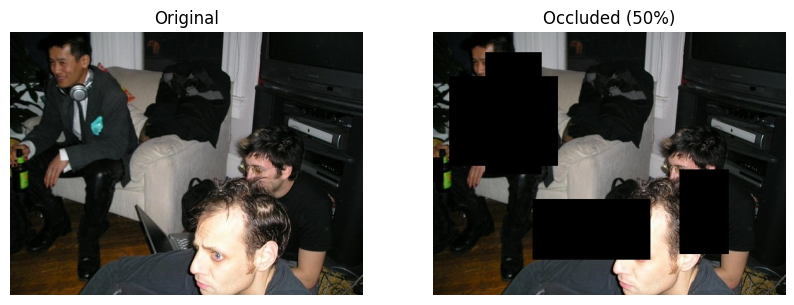

In [16]:
from pathlib import Path

# pick one sample
img_name = list(Path("ExDark_OCC/occ50/images").glob("*"))[0].name

orig = cv2.imread(f"ExDark_OCC/clean/images/{img_name}")
occ  = cv2.imread(f"ExDark_OCC/occ50/images/{img_name}")

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(occ, cv2.COLOR_BGR2RGB))
plt.title("Occluded (50%)")
plt.axis("off")

plt.show()

In [17]:
!zip -r ExDark_OCC.zip ExDark_OCC

Streaming output truncated to the last 5000 lines.
  adding: ExDark_OCC/clean/labels/2015_05471.txt (deflated 57%)
  adding: ExDark_OCC/clean/labels/2015_01086.txt (deflated 14%)
  adding: ExDark_OCC/clean/labels/2015_02800.txt (deflated 62%)
  adding: ExDark_OCC/clean/labels/2015_06499.txt (deflated 15%)
  adding: ExDark_OCC/clean/labels/2015_05016.txt (deflated 39%)
  adding: ExDark_OCC/clean/labels/2015_01875.txt (deflated 66%)
  adding: ExDark_OCC/clean/labels/2015_04543.txt (deflated 48%)
  adding: ExDark_OCC/clean/labels/2015_02641.txt (deflated 49%)
  adding: ExDark_OCC/clean/labels/2015_02516.txt (deflated 57%)
  adding: ExDark_OCC/clean/labels/2015_04291.txt (deflated 47%)
  adding: ExDark_OCC/clean/labels/2015_02165.txt (deflated 38%)
  adding: ExDark_OCC/clean/labels/2015_05991.txt (deflated 41%)
  adding: ExDark_OCC/clean/labels/2015_01857.txt (deflated 68%)
  adding: ExDark_OCC/clean/labels/2015_04259.txt (deflated 58%)
  adding: ExDark_OCC/clean/labels/2015_03866.txt (def

In [19]:
!pip install kaggle


In [21]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [22]:
!kaggle datasets list

ref                                                                title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                     Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000           6970        174                1  
nalisha/job-salary-prediction-dataset                              Job Salary Prediction Dataset                          3144815  2026-03-16 19:54:33.843000          13527        306                1  
sohaibdevv/ai-and-student-life-2026-the-new-normal                 How AI is Changing Life | AI and Student Life 2026       21917  2026-04-11 11:52:06.050000            663         24     

In [23]:
!mkdir kaggle_upload
!cp -r ExDark_OCC kaggle_upload/

In [24]:
import json

meta = {
    "title": "ExDark YOLO Occlusion Dataset",
    "id": "dakshivashishtha/exdark-occluded",
    "licenses": [{"name": "CC0-1.0"}]
}

with open("kaggle_upload/dataset-metadata.json", "w") as f:
    json.dump(meta, f)

In [26]:
!kaggle datasets create -p kaggle_upload --dir-mode zip

Starting upload for file ExDark_OCC.zip
100% 4.84G/4.84G [00:44<00:00, 116MB/s]
Upload successful: ExDark_OCC.zip (5GB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/dakshivashishtha/exdark-occluded
